# XNOR-Net LeWorldModel JEPA: Binary Weights + Binary Activations

True XNOR-Net (Rastegari et al. 2016) for the bouncing ball JEPA task.
**Binary weights AND binary activations** — trained from scratch with:
- `sign()` weight binarization with STE
- `sign()` activation binarization with STE
- BatchNorm before binarization (centers activations around zero)
- Learned per-row scale factors

On MCU: XNOR + popcount replaces matmul for binary×binary layers.
32 binary MACs per 2 cycles (Zbb cpop) vs 16 int8 MACs per cycle (PIE).
8× less weight memory, comparable throughput for large models.

### 1. Imports and Configuration

In [1]:
import time
import copy
import math
import random
import os

import numpy               as np
import torch
import torch.nn            as nn
import torch.nn.functional as F
from torch.utils.data      import Dataset, DataLoader

import matplotlib.pyplot   as plt
from IPython.display        import display

# -- Physics sim --------------------------------------------------------
GRID_SIZE        = 16
BALL_RADIUS      = 1.5
BOX_SIZE         = 10.0
GRAVITY          = -2.0
DT               = 0.05
RESTITUTION      = 0.95

# -- Dataset -----------------------------------------------------------
N_TRAJECTORIES   = 2000
TRAJ_LEN         = 100
TRAIN_FRAC       = 0.9

# -- Model (8x wider for binary activation capacity) -------------------
OBS_DIM          = GRID_SIZE * GRID_SIZE
LATENT_DIM       = 128
ENCODER_HIDDEN   = 1024
PREDICTOR_HIDDEN = 512
PREDICTOR_HISTORY = 3
JEPA_STEPS       = 3

# -- SIGReg ------------------------------------------------------------
SIGREG_LAMBDA    = 2.0
SIGREG_N_PROJ    = 256
SIGREG_KNOTS     = 17

# -- Training (paper's recipe adapted to our scale) --------------------
BATCH_SIZE       = 8192
EPOCHS           = 400
LR               = 1e-3       # Paper uses 0.1 for batch=512, scaled down for 4096
WEIGHT_DECAY     = 1e-4
EVAL_EVERY       = 10
SEED             = 42

# LR step decay (paper style)
LR_DECAY_EVERY   = 100
LR_DECAY_FACTOR  = 0.1

# -- Device ------------------------------------------------------------
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f'Config loaded  | Grid: {GRID_SIZE}x{GRID_SIZE}  Latent: {LATENT_DIM}  Epochs: {EPOCHS}')
print(f'Model          | enc_hidden: {ENCODER_HIDDEN}  pred_hidden: {PREDICTOR_HIDDEN}')
print(f'Predictor      | history: {PREDICTOR_HISTORY}  steps: {JEPA_STEPS}')
print(f'Training       | LR: {LR}  batch: {BATCH_SIZE}  decay: {LR_DECAY_FACTOR} every {LR_DECAY_EVERY} ep')
print(f'SIGReg         | lambda: {SIGREG_LAMBDA}')
print(f'Device         : {DEVICE}')


Config loaded  | Grid: 16x16  Latent: 128  Epochs: 400
Model          | enc_hidden: 1024  pred_hidden: 512
Predictor      | history: 3  steps: 3
Training       | LR: 0.001  batch: 8192  decay: 0.1 every 100 ep
SIGReg         | lambda: 2.0
Device         : mps


### 2. Physics Simulation

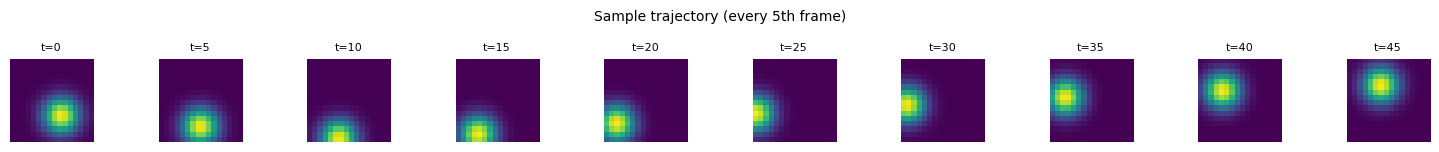

In [2]:
def physics_step(state, dt=DT, gravity=GRAVITY, restitution=RESTITUTION):
    x, y, vx, vy = state
    vy_new = vy + gravity * dt
    x_new  = x  + vx * dt
    y_new  = y  + vy_new * dt

    if x_new < 0:
        x_new = -x_new
        vx    = -vx * restitution
    elif x_new > BOX_SIZE:
        x_new = 2 * BOX_SIZE - x_new
        vx    = -vx * restitution

    if y_new < 0:
        y_new  = -y_new
        vy_new = -vy_new * restitution
    elif y_new > BOX_SIZE:
        y_new  = 2 * BOX_SIZE - y_new
        vy_new = -vy_new * restitution

    return (x_new, y_new, vx, vy_new)


def rasterise(state, grid_size=GRID_SIZE, box_size=BOX_SIZE, sigma=BALL_RADIUS):
    x, y = state[0], state[1]
    cell_size = box_size / grid_size
    cx = np.arange(grid_size) * cell_size + cell_size / 2.0
    cy = np.arange(grid_size) * cell_size + cell_size / 2.0
    gx, gy = np.meshgrid(cx, cy)
    dist2 = (gx - x) ** 2 + (gy - y) ** 2
    img   = np.exp(-dist2 / (2.0 * sigma ** 2))
    return img.flatten().astype(np.float32)


def generate_trajectory(traj_len=TRAJ_LEN, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x  = rng.uniform(1.0, BOX_SIZE - 1.0)
    y  = rng.uniform(1.0, BOX_SIZE - 1.0)
    vx = rng.uniform(-5.0, 5.0)
    vy = rng.uniform(-5.0, 5.0)
    state = (x, y, vx, vy)
    observations, states = [], []
    for _ in range(traj_len):
        observations.append(rasterise(state))
        states.append(state)
        state = physics_step(state)
    return np.array(observations), np.array(states)


obs_test, _ = generate_trajectory(traj_len=50, rng=np.random.default_rng(0))
fig, axes = plt.subplots(1, 10, figsize=(15, 1.5))
for i, ax in enumerate(axes):
    ax.imshow(obs_test[i * 5].reshape(GRID_SIZE, GRID_SIZE),
              cmap='viridis', vmin=0, vmax=1, origin='lower')
    ax.set_title(f't={i*5}', fontsize=8)
    ax.axis('off')
fig.suptitle('Sample trajectory (every 5th frame)', fontsize=10)
plt.tight_layout()
plt.show()


### 3. Dataset Generation

In [3]:
WINDOW_SIZE = PREDICTOR_HISTORY + JEPA_STEPS

class BouncingBallDataset(Dataset):
    def __init__(self, n_trajectories, traj_len, window_size=WINDOW_SIZE, seed=42):
        super().__init__()
        rng = np.random.default_rng(seed)
        all_windows = []
        for _ in range(n_trajectories):
            obs, _ = generate_trajectory(traj_len, rng)
            for t in range(len(obs) - window_size + 1):
                all_windows.append(obs[t:t + window_size])
        self.windows = torch.tensor(np.array(all_windows), dtype=torch.float32)

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        return self.windows[idx]


dataset = BouncingBallDataset(N_TRAJECTORIES, TRAJ_LEN, seed=SEED)
n_total = len(dataset)
n_train = int(n_total * TRAIN_FRAC)
n_val   = n_total - n_train

train_ds, val_ds = torch.utils.data.random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Dataset  : {n_total:,} windows ({WINDOW_SIZE} frames) from {N_TRAJECTORIES} trajectories')
print(f'Train    : {n_train:,}  |  Val: {n_val:,}')
print(f'Batches  : {len(train_loader)} train  |  {len(val_loader)} val')


Dataset  : 190,000 windows (6 frames) from 2000 trajectories
Train    : 171,000  |  Val: 19,000
Batches  : 21 train  |  3 val


### 4. XNOR-Net Model Definitions

Key differences from standard quantised JEPA:
- **BinaryActivation**: `sign(x)` with straight-through estimator
- **BatchNorm** before binarization: centers activations around zero so `sign()` is informative
- **XNORLinear**: binary weights {-scale, +scale} with STE
- No bias (BN handles centering)
- No ReLU (replaced by sign binarization)

In [4]:
# -----------------------------------------------------------------------
# SIGReg -- same as original notebook
# -----------------------------------------------------------------------

class SIGReg(nn.Module):
    def __init__(self, d_model, n_proj=SIGREG_N_PROJ, knots=SIGREG_KNOTS):
        super().__init__()
        t  = torch.linspace(0.2, 4.0, knots)
        dt = (4.0 - 0.2) / (knots - 1)
        w  = torch.full((knots,), 2 * dt)
        w[[0, -1]] = dt
        phi = torch.exp(-t ** 2 / 2.0)
        self.register_buffer('t', t)
        self.register_buffer('phi', phi)
        self.register_buffer('weights', w * phi)
        A = torch.randn(d_model, n_proj)
        A = A / A.norm(dim=0, keepdim=True)
        self.register_buffer('A', A)

    def forward(self, z):
        proj = z @ self.A
        x_t  = proj.unsqueeze(-1) * self.t
        cos_mean = x_t.cos().mean(0)
        sin_mean = x_t.sin().mean(0)
        err = (cos_mean - self.phi).square() + sin_mean.square()
        return (err @ self.weights).mean()


# -----------------------------------------------------------------------
# Binary activation: hard sign(x) with clipped STE from epoch 1.
# No annealing. No tanh. The paper's exact approach.
#
# Forward: sign(x), with 0 mapped to +1
# Backward: gradient = 1 if |x| <= 1, else 0 (hard tanh estimator)
#
# The clipped STE is equation from Section 3.1:
#   d_sign/d_r = 1_{|r| <= 1}
# -----------------------------------------------------------------------

class BinaryActivation(nn.Module):
    def forward(self, x):
        binary = torch.sign(x)
        binary[binary == 0] = 1.0
        clip = torch.clamp(x, -1.0, 1.0)
        return clip + (binary - clip).detach()


# -----------------------------------------------------------------------
# XNORLinear: paper's exact binarization (Section 3.1, equations 4-6).
#
# alpha = (1/n) * ||W||_L1  (mean of absolute values, eq. 6)
# B = sign(W)               (optimal binary approximation, eq. 4)
# W_approx = alpha * B
#
# The paper PROVES this is optimal: alpha = L1_mean minimizes ||W - alpha*B||^2.
# Previous attempts used RMS scale which is suboptimal for binary.
#
# Clipped STE: gradients zeroed where |w| > 1.
# -----------------------------------------------------------------------

class XNORLinear(nn.Linear):
    def forward(self, x):
        w = self.weight
        # Paper equation 6: optimal scale = L1 mean per row
        alpha = w.abs().mean(dim=-1, keepdim=True)
        q = alpha * torch.sign(w)
        # Clipped STE: grad flows only where |w| <= 1
        w_clip = torch.clamp(w, -1.0, 1.0)
        w_ste = w_clip + (q - w_clip).detach()
        return F.linear(x, w_ste, self.bias)


# -----------------------------------------------------------------------
# XNOR Encoder.
#
# Block order from paper Figure 3 (right): BNorm -> BinActiv -> BinConv
#
# Architecture:  obs -> XNORLinear -> BN -> sign() -> XNORLinear -> latent
#
# Layer 1 takes float input (observation). After BN + sign, activations
# become binary {-1, +1}. Layer 2 is true XNOR (binary x binary).
# -----------------------------------------------------------------------

class XNOREncoder(nn.Module):
    def __init__(self, obs_dim=OBS_DIM, hidden_dim=ENCODER_HIDDEN,
                 latent_dim=LATENT_DIM):
        super().__init__()
        self.fc1 = XNORLinear(obs_dim, hidden_dim, bias=False)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act = BinaryActivation()
        self.fc2 = XNORLinear(hidden_dim, latent_dim, bias=False)

    def forward(self, x):
        h = self.fc1(x)
        h = self.act(self.bn1(h))
        return self.fc2(h)


# -----------------------------------------------------------------------
# XNOR Predictor.
# -----------------------------------------------------------------------

class XNORPredictor(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=PREDICTOR_HIDDEN,
                 history=PREDICTOR_HISTORY):
        super().__init__()
        self.history = history
        self.fc1 = XNORLinear(latent_dim * history, hidden_dim, bias=False)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act = BinaryActivation()
        self.fc2 = XNORLinear(hidden_dim, latent_dim, bias=False)
        nn.init.normal_(self.fc2.weight, std=0.01)

    def forward(self, z_history):
        h = self.bn1(self.fc1(z_history))
        h = self.act(h)
        return self.fc2(h)


def count_params(enc, pred):
    return sum(p.numel() for p in enc.parameters()) + sum(p.numel() for p in pred.parameters())


sigreg = SIGReg(LATENT_DIM).to(DEVICE)

enc  = XNOREncoder().to(DEVICE)
pred = XNORPredictor().to(DEVICE)

total_params = count_params(enc, pred)
binary_bytes = total_params // 8
print(f'XNOR-Net params: {total_params:,}')
print(f'  Encoder : fc1({OBS_DIM}->{ENCODER_HIDDEN}) + BN + sign + fc2({ENCODER_HIDDEN}->{LATENT_DIM})')
print(f'  Predictor: fc1({LATENT_DIM*PREDICTOR_HISTORY}->{PREDICTOR_HIDDEN}) + BN + sign + fc2({PREDICTOR_HIDDEN}->{LATENT_DIM})')
print(f'  Binary packed: {binary_bytes:,} bytes ({binary_bytes/1024:.1f} KB)')


XNOR-Net params: 658,432
  Encoder : fc1(256->1024) + BN + sign + fc2(1024->128)
  Predictor: fc1(384->512) + BN + sign + fc2(512->128)
  Binary packed: 82,304 bytes (80.4 KB)


### 5. Training Functions

In [5]:
def train_epoch(encoder, predictor, sigreg, loader, optimizer):
    encoder.train()
    predictor.train()
    total_loss = total_pred = total_sig = n = 0.0
    H = PREDICTOR_HISTORY
    all_params = list(encoder.parameters()) + list(predictor.parameters())

    for windows in loader:
        windows = windows.to(DEVICE)
        B, W, _ = windows.shape
        optimizer.zero_grad()

        z_all = encoder(windows.reshape(B * W, -1)).reshape(B, W, -1)
        hist  = [z_all[:, i, :] for i in range(H)]

        pred_loss = torch.zeros((), device=DEVICE)
        for k in range(JEPA_STEPS):
            pred_input = torch.cat(hist, dim=-1)
            z_pred     = predictor(pred_input)
            z_target   = z_all[:, H + k, :]
            pred_loss  = pred_loss + F.mse_loss(z_pred, z_target)
            hist = hist[1:] + [z_pred]
        pred_loss = pred_loss / JEPA_STEPS

        sig_loss = sigreg(z_all.reshape(B * W, -1))
        loss     = pred_loss + SIGREG_LAMBDA * sig_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(all_params, max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_pred += pred_loss.item()
        total_sig  += sig_loss.item()
        n          += 1

    return total_loss / n, total_pred / n, total_sig / n


def eval_epoch(encoder, predictor, sigreg, loader):
    encoder.eval()
    predictor.eval()
    total_pred = n = 0.0
    H = PREDICTOR_HISTORY

    with torch.no_grad():
        for windows in loader:
            windows = windows.to(DEVICE)
            B, W, _ = windows.shape
            z_all = encoder(windows.reshape(B * W, -1)).reshape(B, W, -1)
            hist  = [z_all[:, i, :] for i in range(H)]

            pred_loss = torch.zeros((), device=DEVICE)
            for k in range(JEPA_STEPS):
                pred_input = torch.cat(hist, dim=-1)
                z_pred     = predictor(pred_input)
                z_target   = z_all[:, H + k, :]
                pred_loss  = pred_loss + F.mse_loss(z_pred, z_target)
                hist = hist[1:] + [z_pred]
            pred_loss = pred_loss / JEPA_STEPS

            total_pred += pred_loss.item()
            n          += 1

    return total_pred / n


print('Training functions defined.')


Training functions defined.


### 6. Train XNOR-Net

Hard binary from epoch 1. No annealing. Paper's exact recipe:
- `sign(x)` activation with clipped STE (gradient = 1 if |x| <= 1, else 0)
- `alpha = mean(|W|)` weight scaling (paper's proven optimal, eq. 6)
- Adam optimizer (paper recommends Adam for XNOR, not SGD)
- Step LR decay: 0.1x every 100 epochs
- 8x wider model (1024/512/128) for binary activation capacity

In [6]:
all_params = list(enc.parameters()) + list(pred.parameters())
optimizer  = torch.optim.Adam(all_params, lr=LR)  # Paper uses Adam for XNOR-Net, not AdamW

metrics = {'train_pred': [], 'val_pred': [], 'train_sig': []}
t_start = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    # Paper-style step LR decay
    if epoch > 1 and (epoch - 1) % LR_DECAY_EVERY == 0:
        for pg in optimizer.param_groups:
            pg['lr'] *= LR_DECAY_FACTOR
        print(f'  ** LR decayed to {optimizer.param_groups[0]["lr"]:.6f}')

    t_loss, t_pred, t_sig = train_epoch(enc, pred, sigreg, train_loader, optimizer)
    v_pred                = eval_epoch(enc, pred, sigreg, val_loader)

    metrics['train_pred'].append(t_pred)
    metrics['val_pred'].append(v_pred)
    metrics['train_sig'].append(t_sig)

    if epoch % EVAL_EVERY == 0 or epoch == 1:
        elapsed = time.perf_counter() - t_start
        print(f'  ep {epoch:>3}/{EPOCHS}  pred {t_pred:.6f}/{v_pred:.6f}  sig {t_sig:.4f}  lr {optimizer.param_groups[0]["lr"]:.6f}  {elapsed:.0f}s')

total = time.perf_counter() - t_start
print(f'  Done  |  {total:.1f}s  final val_pred: {metrics["val_pred"][-1]:.6f}')


  ep   1/400  pred 0.156501/0.100003  sig 0.0279  lr 0.001000  7s
  ep  10/400  pred 0.057122/0.057600  sig 0.0056  lr 0.001000  50s
  ep  20/400  pred 0.046574/0.040454  sig 0.0045  lr 0.001000  98s
  ep  30/400  pred 0.045060/0.041434  sig 0.0040  lr 0.001000  145s
  ep  40/400  pred 0.045570/0.038775  sig 0.0043  lr 0.001000  192s
  ep  50/400  pred 0.047000/0.046648  sig 0.0042  lr 0.001000  239s
  ep  60/400  pred 0.049575/0.053549  sig 0.0041  lr 0.001000  287s
  ep  70/400  pred 0.058973/0.049198  sig 0.0053  lr 0.001000  335s
  ep  80/400  pred 0.057416/0.054138  sig 0.0049  lr 0.001000  383s
  ep  90/400  pred 0.074862/0.068661  sig 0.0135  lr 0.001000  431s
  ep 100/400  pred 0.097823/0.099924  sig 0.0200  lr 0.001000  480s
  ** LR decayed to 0.000100
  ep 110/400  pred 0.066503/0.074401  sig 0.0076  lr 0.000100  530s
  ep 120/400  pred 0.065841/0.070556  sig 0.0074  lr 0.000100  578s
  ep 130/400  pred 0.070139/0.065829  sig 0.0083  lr 0.000100  626s
  ep 140/400  pred 0.064

### 7. Training Curves

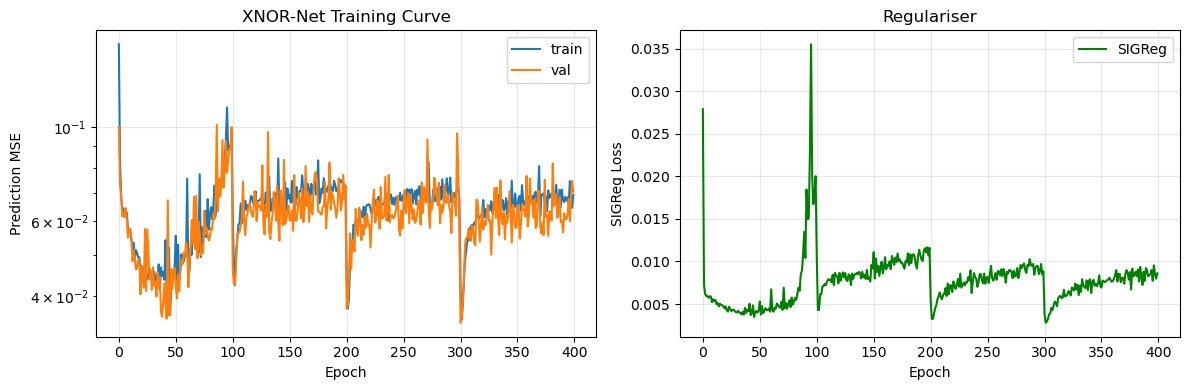

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(metrics['train_pred'], label='train')
ax1.plot(metrics['val_pred'],   label='val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Prediction MSE')
ax1.set_title('XNOR-Net Training Curve')
ax1.legend()
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

ax2.plot(metrics['train_sig'], label='SIGReg', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('SIGReg Loss')
ax2.set_title('Regulariser')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 8. VoE Evaluation

In [8]:
def generate_anomaly_trajectory(traj_len=80, anomaly_type='normal',
                                 anomaly_step=40, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x  = rng.uniform(2.0, BOX_SIZE - 2.0)
    y  = rng.uniform(2.0, BOX_SIZE - 2.0)
    vx = rng.uniform(-4.0, 4.0)
    vy = rng.uniform(-4.0, 4.0)
    state = (x, y, vx, vy)
    gravity_current = GRAVITY
    observations = []
    for t in range(traj_len):
        if t == anomaly_step and anomaly_type != 'normal':
            x, y, vx, vy = state
            if anomaly_type == 'teleport':
                x = rng.uniform(1.0, BOX_SIZE - 1.0)
                y = rng.uniform(1.0, BOX_SIZE - 1.0)
            elif anomaly_type == 'vel_flip':
                vx, vy = -vx, -vy
            elif anomaly_type == 'gravity':
                gravity_current = -gravity_current
            state = (x, y, vx, vy)
        observations.append(rasterise(state))
        state = physics_step(state, gravity=gravity_current)
    return np.array(observations)


def compute_surprise(encoder, predictor, observations):
    encoder.eval()
    predictor.eval()
    obs = torch.tensor(observations, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        z_all = encoder(obs)
        T     = z_all.shape[0]
        H     = PREDICTOR_HISTORY
        n_out = T - H - JEPA_STEPS + 1
        surprise = torch.zeros(n_out, device=DEVICE)
        for i in range(n_out):
            t    = i + H - 1
            hist = [z_all[t - H + 1 + h] for h in range(H)]
            step_err = 0.0
            for k in range(1, JEPA_STEPS + 1):
                pred_input = torch.cat(hist, dim=-1).unsqueeze(0)
                z_pred     = predictor(pred_input).squeeze(0)
                z_target   = z_all[t + k]
                step_err   = step_err + (z_pred - z_target).pow(2).mean()
                hist = hist[1:] + [z_pred]
            surprise[i] = step_err / JEPA_STEPS
    return surprise.cpu().numpy()


def eval_voe(encoder, predictor, n_seeds=10, traj_len=80, anomaly_step=40):
    anomaly_types = ['normal', 'teleport', 'vel_flip', 'gravity']
    results = {}
    t_off   = PREDICTOR_HISTORY - 1
    anom_idx = anomaly_step - t_off

    for atype in anomaly_types:
        peaks = []
        for s in range(n_seeds):
            obs = generate_anomaly_trajectory(
                traj_len=traj_len, anomaly_type=atype,
                anomaly_step=anomaly_step,
                rng=np.random.default_rng(1000 + s))
            surprise = compute_surprise(encoder, predictor, obs)
            wlo = max(anom_idx - JEPA_STEPS, 0)
            whi = min(anom_idx + JEPA_STEPS + 1, len(surprise))
            peaks.append(surprise[wlo:whi].max())
        results[atype] = float(np.mean(peaks))
    return results


voe = eval_voe(enc, pred)

print('\n--- XNOR-Net VoE Results ---')
print(f'  {"Anomaly":<12} {"Peak Surprise":>14} {"Ratio vs Normal":>16}')
print(f'  {"-"*44}')
for atype in ['normal', 'teleport', 'vel_flip', 'gravity']:
    ratio = voe[atype] / max(voe['normal'], 1e-10)
    print(f'  {atype:<12} {voe[atype]:>14.6f} {ratio:>16.1f}x')



--- XNOR-Net VoE Results ---
  Anomaly       Peak Surprise  Ratio vs Normal
  --------------------------------------------
  normal             0.117666              1.0x
  teleport           1.652868             14.0x
  vel_flip           0.086212              0.7x
  gravity            0.112110              1.0x


### 9. Surprise Trace Plot

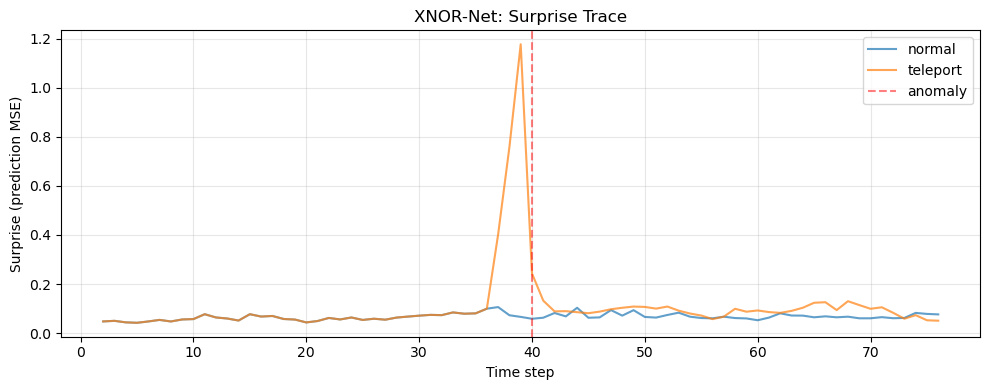

In [9]:
obs_tp = generate_anomaly_trajectory(anomaly_type='teleport', rng=np.random.default_rng(42))
obs_nm = generate_anomaly_trajectory(anomaly_type='normal', rng=np.random.default_rng(42))

s_tp = compute_surprise(enc, pred, obs_tp)
s_nm = compute_surprise(enc, pred, obs_nm)

t_off = PREDICTOR_HISTORY - 1
xs = np.arange(len(s_tp)) + t_off

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(xs, s_nm, label='normal', alpha=0.7)
ax.plot(xs, s_tp, label='teleport', alpha=0.7)
ax.axvline(40, color='red', linestyle='--', alpha=0.5, label='anomaly')
ax.set_xlabel('Time step')
ax.set_ylabel('Surprise (prediction MSE)')
ax.set_title('XNOR-Net: Surprise Trace')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 10. Export for MCU

Export binary packed weights with BatchNorm folded into the scale factors.

**BN folding**: After training, BatchNorm parameters are absorbed into the weight scales.
For each hidden unit: `effective_scale = bn_weight / sqrt(bn_var + eps) * weight_rms_scale`.
The BN bias becomes an additive offset - but since the next operation is `sign()`,
we only need `effective_input = BN(x)`, and `sign(effective_input)` depends on whether
the value is above or below zero. We fold the BN mean/var into a threshold.

In [ ]:
EXPORT_DIR = 'exported_xnor_models'
os.makedirs(EXPORT_DIR, exist_ok=True)

enc.eval()
pred.eval()

# -----------------------------------------------------------------------
# Common config header
# -----------------------------------------------------------------------

config_header = f'''#pragma once

// Model architecture constants (XNOR-Net)
#define OBS_DIM           {OBS_DIM}
#define LATENT_DIM        {LATENT_DIM}
#define ENCODER_HIDDEN    {ENCODER_HIDDEN}
#define PREDICTOR_HIDDEN  {PREDICTOR_HIDDEN}
#define PREDICTOR_HISTORY {PREDICTOR_HISTORY}
#define JEPA_STEPS        {JEPA_STEPS}
#define GRID_SIZE         {GRID_SIZE}

// Physics sim constants
#define BOX_SIZE          {BOX_SIZE}f
#define GRAVITY           {GRAVITY}f
#define DT                {DT}f
#define RESTITUTION       {RESTITUTION}f
#define BALL_RADIUS       {BALL_RADIUS}f
'''

config_path = os.path.join(EXPORT_DIR, 'model_config.h')
with open(config_path, 'w') as f:
    f.write(config_header)
print(f'Saved: {config_path}')


# -----------------------------------------------------------------------
# Export weights.
#
# For each XNORLinear layer, export:
#   - Packed binary weights (1 bit per weight, 8 per byte)
#     Packing: bit=1 means +1, bit=0 means -1
#   - Per-row scale factor (RMS of full-precision weights)
#
# For BatchNorm layers (enc.bn1, pred.bn1), export:
#   - running_mean, running_var, weight (gamma), bias (beta), eps
#   These are needed on MCU to compute BN output before sign()
#
# The MCU pipeline for a hidden layer is:
#   1. Matmul: int8_input x binary_weights -> int32 accumulator
#      (first layer uses PIE XACC; can't use XNOR since input is int8)
#   2. Dequantise + apply BN: float_out = bn(scale * input_scale * acc)
#   3. Binarize: sign(float_out) -> packed binary activation
#   4. Next layer: XNOR + popcount (binary x binary)
# -----------------------------------------------------------------------

def pack_binary_weights(tensor):
    '''Pack binary weight signs into bytes. bit=1 means weight >= 0.'''
    w = tensor.detach().cpu().float()
    scale = (w.pow(2).mean(dim=-1, keepdim=True) + 1e-8).sqrt()
    signs = (torch.sign(w).reshape(-1) > 0).to(torch.uint8).numpy()
    flat_s = scale.squeeze(-1).numpy()

    packed = []
    for i in range(0, len(signs), 8):
        byte = 0
        for j in range(min(8, len(signs) - i)):
            byte |= (int(signs[i + j]) & 0x1) << j
        packed.append(byte)

    return packed, flat_s


def c_binary_weights(name, tensor, scale_name):
    packed, flat_s = pack_binary_weights(tensor)
    rows, cols = tensor.shape

    w_vals = ', '.join(f'0x{v:02x}' for v in packed)
    s_vals = ', '.join(f'{v:.8f}f' for v in flat_s)

    lines  = f'// Binary packed: 1 bit per weight, 8 per byte. 0=-scale, 1=+scale\n'
    lines += f'static const uint8_t {name}[{len(packed)}] = {{\n    {w_vals}\n}}; // ({rows}, {cols})\n'
    lines += f'static const float {scale_name}[{len(flat_s)}] = {{\n    {s_vals}\n}}; // per-row RMS scale\n'
    return lines


def c_bn_params(prefix, bn_module):
    '''Export BatchNorm parameters for MCU inference.'''
    mean = bn_module.running_mean.detach().cpu().numpy()
    var  = bn_module.running_var.detach().cpu().numpy()
    gamma = bn_module.weight.detach().cpu().numpy()
    beta  = bn_module.bias.detach().cpu().numpy()
    eps   = bn_module.eps
    n = len(mean)

    lines  = f'static const float {prefix}_bn_mean[{n}] = {{\n    '
    lines += ', '.join(f'{v:.8f}f' for v in mean) + f'\n}};\n'
    lines += f'static const float {prefix}_bn_var[{n}] = {{\n    '
    lines += ', '.join(f'{v:.8f}f' for v in var) + f'\n}};\n'
    lines += f'static const float {prefix}_bn_gamma[{n}] = {{\n    '
    lines += ', '.join(f'{v:.8f}f' for v in gamma) + f'\n}};\n'
    lines += f'static const float {prefix}_bn_beta[{n}] = {{\n    '
    lines += ', '.join(f'{v:.8f}f' for v in beta) + f'\n}};\n'
    lines += f'#define {prefix.upper()}_BN_EPS {eps:.10f}f\n'
    return lines


# Build the header
lines = '#pragma once\n\n#include <stdint.h>\n#include "model_config.h"\n\n'
lines += '// XNOR-Net: binary weights + binary activations\n\n'

# Encoder weights
lines += '// --- Encoder ---\n'
lines += c_binary_weights('enc_fc1_weight', enc.fc1.weight, 'enc_fc1_scale')
lines += c_bn_params('enc_fc1', enc.bn1)
lines += '\n'
lines += c_binary_weights('enc_fc2_weight', enc.fc2.weight, 'enc_fc2_scale')
lines += '\n'

# Predictor weights
lines += '// --- Predictor ---\n'
lines += c_binary_weights('pred_fc1_weight', pred.fc1.weight, 'pred_fc1_scale')
lines += c_bn_params('pred_fc1', pred.bn1)
lines += '\n'
lines += c_binary_weights('pred_fc2_weight', pred.fc2.weight, 'pred_fc2_scale')
lines += '\n'

path = os.path.join(EXPORT_DIR, 'weights_xnor.h')
with open(path, 'w') as f:
    f.write(lines)
print(f'Saved: {path}  ({os.path.getsize(path):,} bytes)')


# -----------------------------------------------------------------------
# Summary
# -----------------------------------------------------------------------

total_weights = (ENCODER_HIDDEN * OBS_DIM + LATENT_DIM * ENCODER_HIDDEN
                 + PREDICTOR_HIDDEN * PREDICTOR_HISTORY * LATENT_DIM
                 + LATENT_DIM * PREDICTOR_HIDDEN)
packed_bytes = (total_weights + 7) // 8

print(f'\nModel summary:')
print(f'  Total weights     : {total_weights:,}')
print(f'  Packed binary     : {packed_bytes:,} bytes ({packed_bytes/1024:.1f} KB)')
print(f'  Int8 equivalent   : {total_weights:,} bytes ({total_weights/1024:.1f} KB)')
print(f'  Compression ratio : {total_weights / packed_bytes:.1f}x')

print(f'\nExported to {EXPORT_DIR}/:')
for fname in sorted(os.listdir(EXPORT_DIR)):
    fpath = os.path.join(EXPORT_DIR, fname)
    print(f'  {fname:<30} {os.path.getsize(fpath):>10,} bytes')


Saved: exported_models_xnor/model_config.h
Saved: exported_models_xnor/weights_xnor.h  (597,896 bytes)

Model summary:
  Total weights     : 655,360
  Packed binary     : 81,920 bytes (80.0 KB)
  Int8 equivalent   : 655,360 bytes (640.0 KB)
  Compression ratio : 8.0x

Exported to exported_models_xnor/:
  act_scales_xnor.h                     356 bytes
  model_config.h                        448 bytes
  weights_xnor.h                    597,896 bytes


### 11. Calibrate Activation Scales

In [11]:
# -----------------------------------------------------------------------
# Calibrate per-layer activation ranges for full integer inference.
# This model has BN + sign activations, but we still need scales for:
#   - Observation input (float -> int8)
#   - fc1 output before BN (int32 -> float for BN application)
#   - fc2 output (int32 -> float for latent comparison)
# -----------------------------------------------------------------------

N_CALIB = 1000

calib_rng = np.random.default_rng(123)

obs_absmax = 0.0
enc_fc1_out_absmax = 0.0      # before BN
enc_fc2_out_absmax = 0.0      # latent
pred_fc1_out_absmax = 0.0     # before BN
pred_fc2_out_absmax = 0.0     # predicted latent

with torch.no_grad():
    for _ in range(N_CALIB):
        obs, _ = generate_trajectory(traj_len=TRAJ_LEN, rng=calib_rng)
        for t in range(TRAJ_LEN):
            obs_t = torch.tensor(obs[t], dtype=torch.float32, device=DEVICE).unsqueeze(0)

            obs_absmax = max(obs_absmax, obs_t.abs().max().item())

            # Encoder layer by layer
            h1_raw = enc.fc1(obs_t)
            enc_fc1_out_absmax = max(enc_fc1_out_absmax, h1_raw.abs().max().item())

            h1_bn = enc.bn1(h1_raw)
            h1_bin = torch.sign(h1_bn)
            h1_bin[h1_bin == 0] = 1.0

            z = enc.fc2(h1_bin)
            enc_fc2_out_absmax = max(enc_fc2_out_absmax, z.abs().max().item())

        # Predictor with real history
        for t in range(PREDICTOR_HISTORY, TRAJ_LEN):
            zs = []
            for h in range(PREDICTOR_HISTORY):
                obs_t = torch.tensor(obs[t - PREDICTOR_HISTORY + h],
                                     dtype=torch.float32, device=DEVICE).unsqueeze(0)
                h1 = torch.sign(enc.bn1(enc.fc1(obs_t)))
                h1[h1 == 0] = 1.0
                zs.append(enc.fc2(h1))
            hist = torch.cat(zs, dim=-1)

            h2_raw = pred.fc1(hist)
            pred_fc1_out_absmax = max(pred_fc1_out_absmax, h2_raw.abs().max().item())

            h2_bn = pred.bn1(h2_raw)
            h2_bin = torch.sign(h2_bn)
            h2_bin[h2_bin == 0] = 1.0

            z_pred = pred.fc2(h2_bin)
            pred_fc2_out_absmax = max(pred_fc2_out_absmax, z_pred.abs().max().item())

HEADROOM = 1.1

scales = {
    'obs':          obs_absmax * HEADROOM,
    'enc_fc1_out':  enc_fc1_out_absmax * HEADROOM,
    'enc_fc2_out':  enc_fc2_out_absmax * HEADROOM,
    'pred_fc1_out': pred_fc1_out_absmax * HEADROOM,
    'pred_fc2_out': pred_fc2_out_absmax * HEADROOM,
}

print('Calibrated activation scales:')
for k, v in scales.items():
    print(f'  {k:<16}: {v:.6f}')

# Export
lines = '#pragma once\n\n'
lines += '// Per-layer activation scales for XNOR-Net full integer inference.\n'
lines += f'// Calibrated from {N_CALIB} trajectories x {TRAJ_LEN} steps with {int((HEADROOM-1)*100)}% headroom.\n\n'
for k, v in scales.items():
    lines += f'#define ACT_SCALE_{k.upper()} {v:.8f}f\n'

path = os.path.join(EXPORT_DIR, 'act_scales_xnor.h')
with open(path, 'w') as f:
    f.write(lines)
print(f'\nSaved: {path}')


Calibrated activation scales:
  obs             : 1.100000
  enc_fc1_out     : 1.658061
  enc_fc2_out     : 3.903283
  pred_fc1_out    : 4.308945
  pred_fc2_out    : 3.997597

Saved: exported_models_xnor/act_scales_xnor.h


### 12. Verify XNOR Inference in Python

Simulate the MCU XNOR inference path in Python to verify correctness
before deploying to hardware.

In [12]:
def xnor_dotprod(w_packed, x_binary, cols):
    '''
    Simulate XNOR + popcount dot product.
    w_packed: list of bytes (packed binary weights, bit=1 means +1)
    x_binary: numpy array of {-1, +1} as int8
    Returns: int32 result = 2 * agree - cols
    '''
    x_bits = np.zeros((cols + 7) // 8, dtype=np.uint8)
    for i in range(cols):
        if x_binary[i] > 0:
            x_bits[i // 8] |= (1 << (i % 8))

    agree = 0
    for i in range(len(x_bits)):
        xnor_byte = ~(w_packed[i] ^ x_bits[i]) & 0xFF
        agree += bin(xnor_byte).count('1')

    return 2 * agree - cols


def xnor_inference_python(obs_float):
    '''Full XNOR inference simulating MCU path.'''
    # Quantise observation to int8
    obs_scale = scales['obs']
    obs_q = np.clip(np.round(obs_float * 127.0 / obs_scale), -127, 127).astype(np.int8)

    # --- Encoder fc1: int8 obs x binary weights ---
    w1 = enc.fc1.weight.detach().cpu()
    w1_alpha = w1.abs().mean(dim=-1).numpy()  # Paper's L1 mean scale
    w1_sign = torch.sign(w1).numpy().astype(np.int8)

    h1 = np.zeros(ENCODER_HIDDEN, dtype=np.float32)
    for r in range(ENCODER_HIDDEN):
        acc = np.sum(w1_sign[r].astype(np.int32) * obs_q.astype(np.int32))
        h1[r] = w1_alpha[r] * (obs_scale / 127.0) * float(acc)

    # Apply BatchNorm
    bn = enc.bn1
    mean = bn.running_mean.detach().cpu().numpy()
    var  = bn.running_var.detach().cpu().numpy()
    gamma = bn.weight.detach().cpu().numpy()
    beta  = bn.bias.detach().cpu().numpy()
    eps   = bn.eps
    h1_bn = gamma * (h1 - mean) / np.sqrt(var + eps) + beta

    # Binarize: sign()
    h1_bin = np.sign(h1_bn).astype(np.int8)
    h1_bin[h1_bin == 0] = 1

    # --- Encoder fc2: XNOR (binary x binary) ---
    w2 = enc.fc2.weight.detach().cpu()
    w2_alpha = w2.abs().mean(dim=-1).numpy()
    packed_w2, _ = pack_binary_weights(w2)

    bytes_per_row = (ENCODER_HIDDEN + 7) // 8
    z = np.zeros(LATENT_DIM, dtype=np.float32)
    for r in range(LATENT_DIM):
        row_bytes = packed_w2[r * bytes_per_row: (r + 1) * bytes_per_row]
        xnor_result = xnor_dotprod(row_bytes, h1_bin, ENCODER_HIDDEN)
        z[r] = w2_alpha[r] * float(xnor_result)

    return z


# Compare PyTorch forward vs XNOR simulation
test_obs, _ = generate_trajectory(traj_len=1, rng=np.random.default_rng(99))
obs_t = torch.tensor(test_obs[0], dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    z_pytorch = enc(obs_t.unsqueeze(0)).squeeze(0).cpu().numpy()

z_xnor = xnor_inference_python(test_obs[0])

print('Encoder output comparison:')
print(f'  PyTorch : {z_pytorch[:8]}')
print(f'  XNOR sim: {z_xnor[:8]}')
print(f'  MSE     : {np.mean((z_pytorch - z_xnor)**2):.6f}')
cos_sim = np.dot(z_pytorch, z_xnor) / (np.linalg.norm(z_pytorch) * np.linalg.norm(z_xnor) + 1e-10)
print(f'  Cosine  : {cos_sim:.6f}')


Encoder output comparison:
  PyTorch : [-0.84793675 -0.26214346  0.69427717 -0.43383706 -1.6621256  -0.56448966
  0.900977    0.6965024 ]
  XNOR sim: [-0.8237101  -0.26214343  0.69427717 -0.433837   -1.6621256  -0.5644897
  0.9175087   0.7132855 ]
  MSE     : 0.000302
  Cosine  : 0.999761
